In [22]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [23]:


df = pd.read_csv("/content/drive/MyDrive/MedAssist-AI/backend/ml/datasets/filtered_240_disease_dataset.csv")

print(df.head())
print(df.shape)


         diseases  anxiety and nervousness  depression  shortness of breath  \
0  panic disorder                        1           0                    1   
1  panic disorder                        0           0                    1   
2  panic disorder                        1           1                    1   
3  panic disorder                        1           0                    0   
4  panic disorder                        1           1                    0   

   depressive or psychotic symptoms  sharp chest pain  dizziness  insomnia  \
0                                 1                 0          0         0   
1                                 1                 0          1         1   
2                                 1                 0          1         1   
3                                 1                 0          1         1   
4                                 0                 0          0         1   

   abnormal involuntary movements  chest tightness  ... 

In [24]:
df.isna().sum()

,0
diseases,0
anxiety and nervousness,0
depression,0
shortness of breath,0
depressive or psychotic symptoms,0
...,...
hip weakness,0
back swelling,0
ankle stiffness or tightness,0
ankle weakness,0


In [25]:
X = df.drop("diseases", axis=1)
y = df["diseases"]

print(X.shape)
print(y.shape)

(151556, 377)
(151556,)


In [26]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
print(X_train.shape)
print(X_test.shape)

(121244, 377)
(30312, 377)


In [29]:
results = []

def evaluate_model(model, name):

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    prec = precision_score(
        y_test,
        pred,
        average="weighted",
        zero_division=0
    )

    rec = recall_score(
        y_test,
        pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        pred,
        average="weighted"
    )

    results.append([name, acc, prec, rec, f1])

    print("="*50)
    print(name)
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)

    return model

In [30]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=3000,
    random_state=42
)

lr = evaluate_model(lr, "Logistic Regression")

Logistic Regression
Accuracy : 0.8624637107416204
Precision: 0.8695611508377882
Recall   : 0.8624637107416204
F1 Score : 0.8634172641270091


In [31]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb = evaluate_model(nb, "Naive Bayes")

Naive Bayes
Accuracy : 0.865993665874901
Precision: 0.8915597820580682
Recall   : 0.865993665874901
F1 Score : 0.8688931992218581


In [32]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=5,
    random_state=42
)

dt = evaluate_model(dt, "Decision Tree")

Decision Tree
Accuracy : 0.1372063869094748
Precision: 0.25635447573131925
Recall   : 0.1372063869094748
F1 Score : 0.16797719886412896


In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=2
)

rf = evaluate_model(rf, "Random Forest")

Random Forest
Accuracy : 0.759006334125099
Precision: 0.8205542983047064
Recall   : 0.759006334125099
F1 Score : 0.7652313088936944


In [34]:
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=2
)

et = evaluate_model(et, "Extra Trees")

Extra Trees
Accuracy : 0.7403008709422011
Precision: 0.8133519061036051
Recall   : 0.7403008709422011
F1 Score : 0.7506398601730513


In [35]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn = evaluate_model(knn, "KNN")

KNN
Accuracy : 0.8282198469253101
Precision: 0.8325150767062963
Recall   : 0.8282198469253101
F1 Score : 0.8287752056081852


In [36]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df = results_df.sort_values(
    "Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
1,Naive Bayes,0.865994,0.891560,0.865994,0.868893
0,Logistic Regression,0.862464,0.869561,0.862464,0.863417
5,KNN,0.828220,0.832515,0.828220,0.828775
3,Random Forest,0.759006,0.820554,0.759006,0.765231
4,Extra Trees,0.740301,0.813352,0.740301,0.750640
2,Decision Tree,0.137206,0.256354,0.137206,0.167977


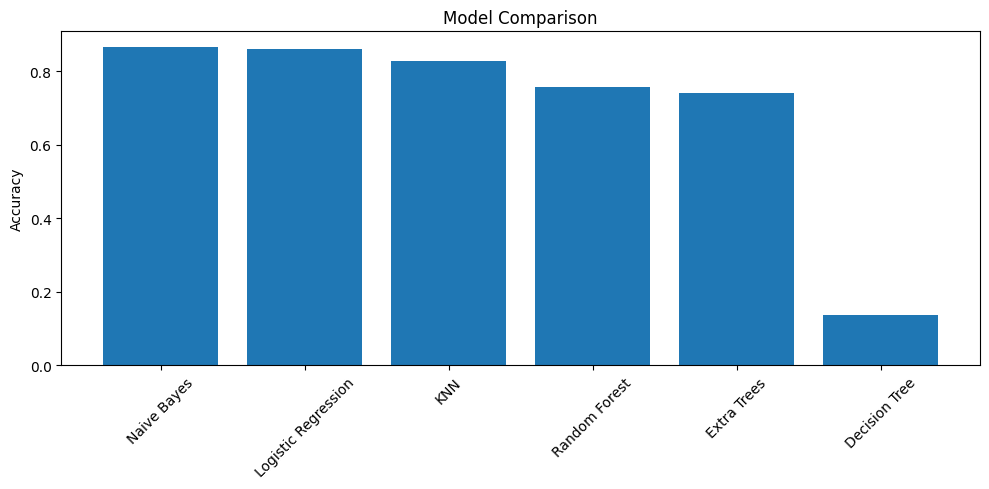

In [37]:
plt.figure(figsize=(10,5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.xticks(rotation=45)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.tight_layout()

plt.savefig("model_comparison.png")

plt.show()

In [38]:
import pandas as pd

from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier, RidgeClassifier, PassiveAggressiveClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

models = {
    "SVM (LinearSVC)": LinearSVC(random_state=42, max_iter=5000),
    "SGDClassifier": SGDClassifier(loss="log_loss", random_state=42),
    "Ridge Classifier": RidgeClassifier(),
    "Passive Aggressive": PassiveAggressiveClassifier(random_state=42)
}

for name, model in models.items():

    print("="*60)
    print(f"Training {name}")
    print("="*60)

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, pred, average='weighted')
    f1 = f1_score(y_test, pred, average='weighted')

    results.append([
        name,
        acc,
        prec,
        rec,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n")
print("="*70)
print("MODEL COMPARISON")
print("="*70)
print(results_df)

Training SVM (LinearSVC)
Training SGDClassifier
Training Ridge Classifier
Training Passive Aggressive


MODEL COMPARISON
                Model  Accuracy  Precision    Recall  F1 Score
0     SVM (LinearSVC)  0.860385   0.865931  0.860385  0.861127
1       SGDClassifier  0.857350   0.861479  0.857350  0.856146
3  Passive Aggressive  0.838579   0.861894  0.838579  0.839688
2    Ridge Classifier  0.720936   0.758038  0.720936  0.699367


In [39]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train, y_train)

pred = svm.predict(X_test)

In [40]:
import joblib
import os

os.makedirs("saved_models", exist_ok=True)

joblib.dump(nb, "saved_models/naive_bayes.pkl")

print("Naive Bayes model saved successfully!")

Naive Bayes model saved successfully!


In [41]:
import joblib
import os

os.makedirs("saved_models", exist_ok=True)

# Save trained Naive Bayes model
joblib.dump(nb, "saved_models/naive_bayes.pkl")

# Save the SAME label encoder used during training
joblib.dump(label_encoder, "saved_models/label_encoder_nb.pkl")

# Save feature column names and their exact order
joblib.dump(list(X.columns), "saved_models/feature_columns.pkl")

print("All files saved successfully!")

All files saved successfully!


In [42]:
list(X.columns)

['anxiety and nervousness',
 'depression',
 'shortness of breath',
 'depressive or psychotic symptoms',
 'sharp chest pain',
 'dizziness',
 'insomnia',
 'abnormal involuntary movements',
 'chest tightness',
 'palpitations',
 'irregular heartbeat',
 'breathing fast',
 'hoarse voice',
 'sore throat',
 'difficulty speaking',
 'cough',
 'nasal congestion',
 'throat swelling',
 'diminished hearing',
 'lump in throat',
 'throat feels tight',
 'difficulty in swallowing',
 'skin swelling',
 'retention of urine',
 'groin mass',
 'leg pain',
 'hip pain',
 'suprapubic pain',
 'blood in stool',
 'lack of growth',
 'emotional symptoms',
 'elbow weakness',
 'back weakness',
 'pus in sputum',
 'symptoms of the scrotum and testes',
 'swelling of scrotum',
 'pain in testicles',
 'flatulence',
 'pus draining from ear',
 'jaundice',
 'mass in scrotum',
 'white discharge from eye',
 'irritable infant',
 'abusing alcohol',
 'fainting',
 'hostile behavior',
 'drug abuse',
 'sharp abdominal pain',
 'feeling 

In [43]:
import joblib
import numpy as np

nb = joblib.load("saved_models/naive_bayes.pkl")
label_encoder = joblib.load("saved_models/label_encoder.pkl")
feature_columns = joblib.load("saved_models/feature_columns.pkl")

print("Model loaded:", type(nb))
print("Number of features:", len(feature_columns))
print("Number of diseases:", len(label_encoder.classes_))

Model loaded: <class 'sklearn.naive_bayes.GaussianNB'>
Number of features: 377
Number of diseases: 240
